In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import datetime
import math
from scipy import stats

In [65]:
df = pd.read_csv("../Datasets/amazon_final.csv")

In [4]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,42675,0,object,8808
1,product_rating,41651,1024,float64,32
2,total_reviews,41651,1024,float64,4414
3,purchased_last_month,32164,10511,float64,30
4,discounted_price,40613,2062,float64,3559
5,original_price,40613,2062,float64,3152
6,is_best_seller,42675,0,object,12
7,is_sponsored,42675,0,object,2
8,coupon,42675,0,object,42
9,buy_box_availability,42675,0,int64,2


In [14]:
peripherals = df[df['product_category'] == 'Computer Peripherals'].copy()
info = info_df(peripherals)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,3517,0,object,783
1,product_rating,3476,41,float64,20
2,total_reviews,3476,41,float64,689
3,purchased_last_month,2703,814,float64,20
4,discounted_price,2993,524,float64,466
5,original_price,2993,524,float64,374
6,is_best_seller,3517,0,object,5
7,is_sponsored,3517,0,object,2
8,coupon,3517,0,object,10
9,buy_box_availability,3517,0,int64,2


## ¿Qué pinta tienen?

In [15]:
from IPython.display import Image, HTML

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = peripherals[(peripherals.original_price < 1000)][['product_title', 'original_price', 'product_image_url']].sample(2)

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

,product_title,original_price,product_image_url
36722,"Godox V1 V1Pro S U Flash for Sony Camera TTL Speedlight, 1/8000 HSS 500 Full Power Flashes, 1.3s Recycle Time, 2.4G Wireless with External Flash SU-1 for Sony Cameras (Godox V1PRO-S USA Version)",329.0,
12500,"Samsung Bluetooth Wireless Mouse Slim, Compact, Silent, for Laptop, Tablet, MacBook, Android, Windows - Black",50.5,


# 1. GRÁFICAS SOBRE LAS VARIABLES RELEVANTES INDIVIDUALES

In [82]:
peripherals_sinDuplicates = peripherals.drop_duplicates().copy()

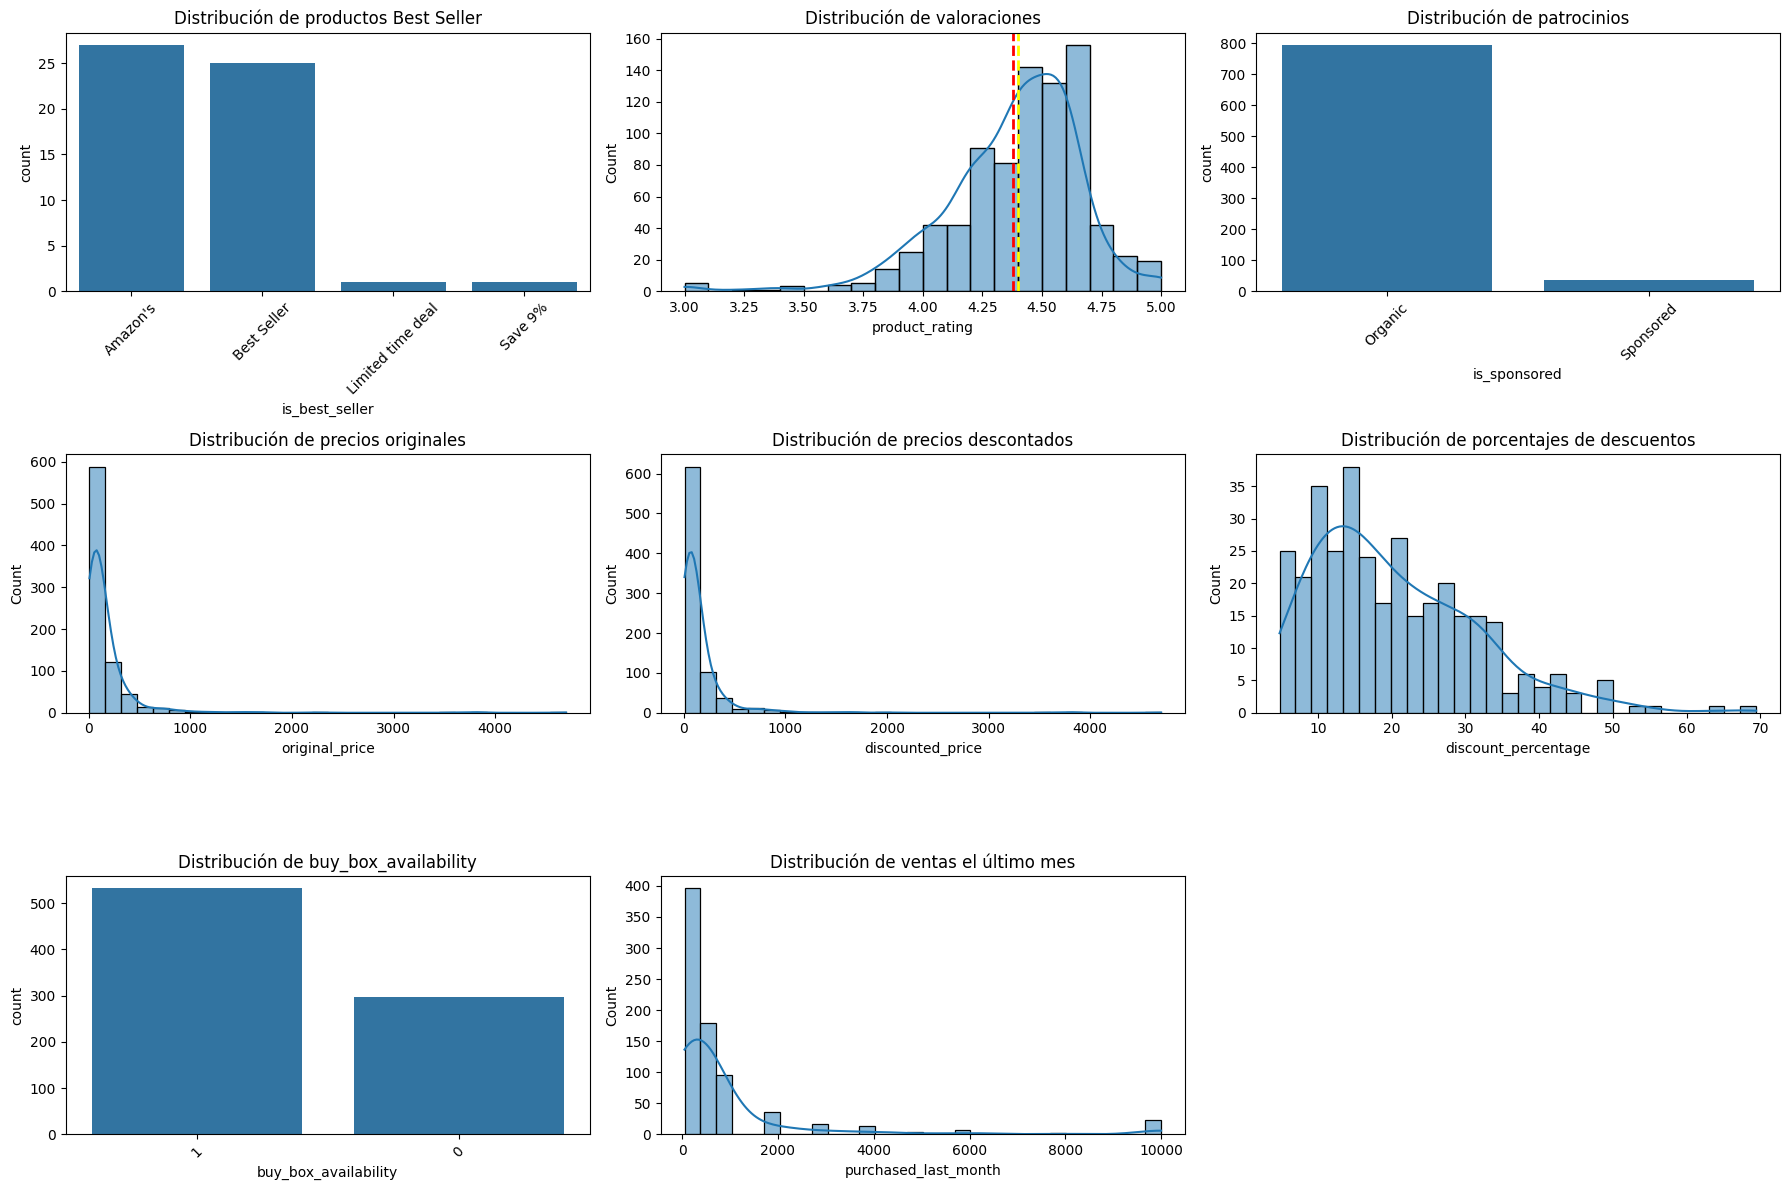

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# FIGURA DE 3 FILAS X 3 COLUMNAS
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

peripherals_sin_NoBadge =  peripherals_sinDuplicates[peripherals_sinDuplicates['is_best_seller'] != 'No Badge']

# Distribución de los valores de best seller
ax = axes[0][0]
sns.countplot(
    data=peripherals_sin_NoBadge,
    x='is_best_seller',
    order=peripherals_sin_NoBadge['is_best_seller'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de productos Best Seller')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# Distribución de las valoraciones de los Laptops
ax = axes[0][1]
sns.histplot(
    peripherals_sinDuplicates['product_rating'].dropna(),
    bins=20, kde=True, ax=ax
)
valoracion_media = peripherals_sinDuplicates.product_rating.mean()
ax.axvline(valoracion_media,color='red', linestyle='--', linewidth=2, label=f'Media: {valoracion_media:.2f}')
valoracion_mediana = peripherals_sinDuplicates.product_rating.median()
ax.axvline(valoracion_mediana,color='yellow', linestyle='--', linewidth=2, label=f'Media: {valoracion_mediana:.2f}')
ax.set_title('Distribución de valoraciones')
ax.set_visible(True)

# -----------------------------------------------------------
# GRAFICA 3 (OCULTA)
# -----------------------------------------------------------
ax = axes[0][2]
sns.countplot(
    data=peripherals_sinDuplicates,
    x='is_sponsored',
    order=peripherals_sin_NoBadge['is_sponsored'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de patrocinios')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# -----------------------------------------------------------
# GRAFICA 4 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][0]
sns.histplot(
    peripherals_sinDuplicates['original_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios originales')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 5 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][1]
sns.histplot(
    peripherals_sinDuplicates['discounted_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios descontados')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 6 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][2]
sns.histplot(
    peripherals_sinDuplicates[peripherals_sinDuplicates['discount_percentage'] > 0].discount_percentage.dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de porcentajes de descuentos')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 7 (OCULTA)
# -----------------------------------------------------------
ax = axes[2][0]
peripherals_sinDuplicates.buy_box_availability = peripherals_sinDuplicates.buy_box_availability.fillna('No')
sns.countplot(
    data=peripherals_sinDuplicates,
    x='buy_box_availability',
    order=peripherals_sinDuplicates.buy_box_availability.value_counts().index,
    ax=ax
)
ax.set_title('Distribución de buy_box_availability')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

ax = axes[2][1]
sns.histplot(
    peripherals_sinDuplicates['purchased_last_month'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de ventas el último mes')
ax.set_visible(True)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

# 2. OUTLIERS Y RELACIONES ENTRE VARIABLES

Realizando las gráficas de las variables individuales ya he tenido indicios de cuales son los outliers de cada una, de hecho he tenido que filtrar algunas distribuciones para eliminar los outliers de ellas, a continuación los analizaré detalladamente

### 1. Outliers en Precios

In [9]:
import plotly.express as px
fig = px.box(peripherals, x="original_price",width=1000, height=500)
fig.show()

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   coupon                42675 non-null  object 
 9   buy_box_availability  42675 non-null  int64  
 10  sustainability_tags   3408 non-null   object 
 11  product_image_url     42675 non-null  object 
 12  has_coupon            42675 non-null  int64  
 13  product_category      42675 non-null  object 
 14  discount_percentage   40613 non-null  float64
dtypes: float64(6), int6

In [91]:
df.sustainability_tags.value_counts()

sustainability_tags
Small Business                    1341
Carbon impact                      769
Works with Alexa                   425
Energy efficiency                  262
Alexa Built-in                     184
Manufacturing practices            148
Energy efficiency +3 more          121
Energy efficiency +1 more           93
Forestry practices                  18
Safer chemicals +2 more             18
Recycled materials                   7
Recycled materials +2 more           7
Safer chemicals +1 more              6
Recycled materials +3 more           4
Made in Italy                        4
1 sustainability certification       1
Name: count, dtype: int64

In [67]:
df.product_category.value_counts()

product_category
Computer Peripherals                             3517
Office Supplies, Ink & Toner                     3470
Audio, Sound & Recording Gear                    3413
PC Components                                    3280
Protection Plans                                 3068
TV & Video Displays                              2891
Wearables                                        2890
Cameras & Photography                            2871
Power & Batteries                                2767
Laptops                                          2611
Chargers, Adapters & Cables                      2494
Small Gadget Accessories (Cases & Protectors)    2405
Storage & Memory Cards                           1993
Printers & Scanners (Hardware)                    936
Other Electronics                                 903
Mobile Cell Phones & Smartphones                  870
Video Game Consoles & Virtual Reality             694
Smart Home & Security                             559
Networking 

In [68]:
pcComponentes = df[df.product_category == 'PC Components'].copy()
tv_video = df[df.product_category == 'TV & Video Displays'].copy()
audio = df[df.product_category == 'Audio, Sound & Recording Gear'].copy()


In [78]:
len(df)

42675

In [81]:
num_duplicados = df.duplicated().sum()
print(f"Tienes {num_duplicados} filas duplicadas.")

Tienes 33203 filas duplicadas.


In [80]:
len(audio)

3413

In [86]:
num_duplicados = peripherals_sinDuplicates.duplicated().sum()
print(f"Tienes {num_duplicados} filas duplicadas.")

Tienes 0 filas duplicadas.


In [85]:
sample_peripherals = peripherals_sinDuplicates[(peripherals_sinDuplicates.original_price > 3700)]

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,has_coupon,product_category,discount_percentage
9975,"Logitech Rally bar and tap IP Bundle, 1920 Pixels x 1080 Pixels, Graphite",5.0,1.0,NaN,4699.00,4699.00,No Badge,Organic,No Coupon,1,NaN,,0,Computer Peripherals,0.0
15937,Celestron – Origin Intelligent Home Observatory – All-in-one Astroimaging and Stargazing Smart Telescope – 6-inch RASA Telescope – Fully-Automated GoTo Mount – User-Friendly – iOS/Android Compatible,4.4,25.0,NaN,3797.85,3797.85,No Badge,Organic,No Coupon,0,NaN,,0,Computer Peripherals,0.0
17521,Celestron – Origin Intelligent Home Observatory – All-in-one Astroimaging and Stargazing Smart Telescope – 6-inch RASA Telescope – Fully-Automated GoTo Mount – User-Friendly – iOS/Android Compatible,4.4,25.0,NaN,3797.85,3797.85,Amazon's,Organic,No Coupon,0,NaN,,0,Computer Peripherals,0.0


- ordenadores, productos de cámaras, tablets...

### 2. Outliers en Compras el último mes

In [ ]:
fig = px.box(peripherals, x="purchased_last_month",width=1000, height=500)
fig.show()

¿Qué pinta tienen estos productos?

In [ ]:
#LOS PINTO TODOS, PONGO SAMPLE CORTO PARA NO PETAR EL NOTEBOOK
sample_peripherals = peripherals[(peripherals.purchased_last_month > 300)][['product_title', 'purchased_last_month', 'product_image_url']].sample(3)

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

,product_title,purchased_last_month,product_image_url
97,"Logitech C920x HD Pro Webcam, Full HD 1080p/30fps Video, Clear Audio, HD Light Correction, PC Camera Webcam, Works with Skype, Zoom, Facetime, PC, Laptop, Mac, Tablet - Black",10000.0,
3261,"STAEDTLER Noris Jumbo Digital Stylus Pen: No Charging, EMR Palm Rejection, 4.096 Pressure Levels, Hexagonal Shape, Natural Writing and Drawing on Touchscreen Tablet, Laptop, Phone",1000.0,
2316,"UGREEN Bluetooth Transmitter Receiver for 2 AirPods or BT Devices, Bluetooth Wireless Transmitter for Headphones, 3.5mm Aux Audio Jack Adapter for in-Flight TV Car Home Stereo System",2000.0,


- superventas 409 productos por encima de 300 compras el ultimo mes

In [ ]:
fig = px.box(peripherals[(peripherals.purchased_last_month < 400)], x="purchased_last_month",width=1000, height=500)
fig.show()

In [ ]:
fig = px.box(peripherals , x="total_reviews",width=1000, height=500)
fig.show()

### PURCHASED-TOTAL REVIEWS

In [ ]:
peripherals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3517 entries, 9 to 42652
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         3517 non-null   object 
 1   product_rating        3476 non-null   float64
 2   total_reviews         3476 non-null   float64
 3   purchased_last_month  2703 non-null   float64
 4   discounted_price      2993 non-null   float64
 5   original_price        2993 non-null   float64
 6   is_best_seller        3517 non-null   object 
 7   is_sponsored          3517 non-null   object 
 8   coupon                3517 non-null   object 
 9   buy_box_availability  3517 non-null   int64  
 10  sustainability_tags   332 non-null    object 
 11  product_image_url     3517 non-null   object 
 12  has_coupon            3517 non-null   int64  
 13  product_category      3517 non-null   object 
 14  discount_percentage   2993 non-null   float64
dtypes: float64(6), int64(2), 

In [ ]:
import plotly.express as px

# Crear el gráfico de dispersión
fig = px.scatter(
    peripherals, # Asegúrate de usar tu DataFrame limpio
    x="total_reviews",
    y="purchased_last_month",
    title="Relación entre Ventas Mensuales y Total de Reseñas",
    labels={
        "total_reviews": "Número Total de Reseñas",
        "purchased_last_month": "Unidades Vendidas (Último Mes)"
    },
    hover_data=["product_title"], # Al pasar el ratón verás el nombre del producto
    trendline="ols", # Línea de tendencia (requiere statsmodels instalado)
    opacity=0.6 # Transparencia para ver mejor donde se acumulan los puntos
)

# Mostrar el gráfico
fig.show()

In [22]:
fig = px.box(peripherals, x="purchased_last_month",y='is_sponsored',width=700, height=400)
fig.show()

In [ ]:
fig = px.box(peripherals , x="total_reviews",width=700, height=400)
fig.show()

In [24]:
fig = px.box(peripherals[peripherals.total_reviews>20000] , x="total_reviews",width=700, height=400)
fig.show()

In [37]:
fig = px.box(peripherals, x="product_rating",y='is_sponsored',width=700, height=400)
fig.show()

In [63]:
peripherals.is_sponsored.value_counts()

is_sponsored
Organic      2941
Sponsored     576
Name: count, dtype: int64

# 3. TESTS



## 3.1 ¿ Existe una diferencia singificativa entre la valoración de los productos patrocinados y los orgánicos ?

### En el estudio de outliers ya he podido comprobar como podría haber diferencias entre las valoraciones de los productos patrocinados y los que no están patrocinados.

## NORMALIDAD DE PRODUCT_RATING

In [26]:
from tqdm import tqdm
import pandas as pd

def boot(data):
    veces = 10000   # número de medias a generar
    muestra = 300   # tamaño de cada muestra
    medias_rating = []

    for i in tqdm(range(veces)):
        muestra_i = data.sample(muestra, replace=True)   # with replacement
        medias_rating.append(muestra_i.mean())

    df_boot = pd.DataFrame({"medias": medias_rating})
    return df_boot

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def paint(data):
    plt.figure(figsize=(8,5))
    sns.histplot(data, kde=True, bins=30)
    plt.title("Distribución de medias bootstrap de product_rating")
    plt.xlabel("Media del rating (muestras de tamaño 300)")
    plt.show()

    stats.probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot medias bootstrap product_rating")
    plt.show()

In [28]:
from scipy import stats
# Aplicar el test de Shapiro-Wilk

def test_normalidad(test,grupo):
    stat, p = test(grupo)

    print("Estadístico:", stat)
    print("p-valor:", p)

    if p < 0.05:
        print("Los datos NO siguen una distribución normal.")
    else:
        print("Los datos podrían seguir una distribución normal...o no")

100%|██████████| 10000/10000 [00:01<00:00, 9697.30it/s]


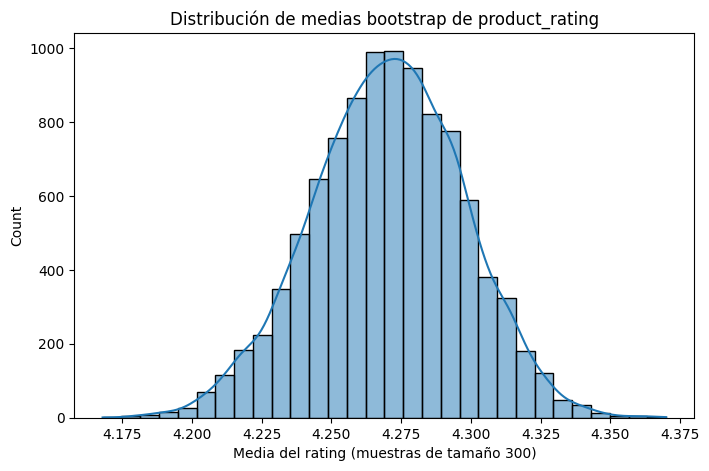

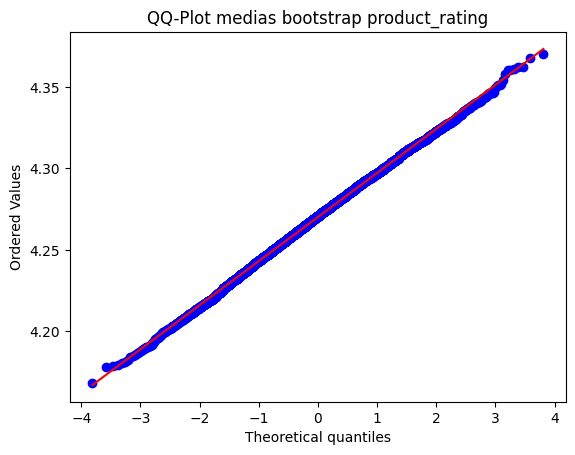

In [29]:
data = peripherals['product_rating'].dropna()

df_boot = boot(data)

paint(df_boot["medias"])

In [30]:
test_normalidad(stats.shapiro,df_boot["medias"])

Estadístico: 0.999361476992438
p-valor: 0.0009794275994811751
Los datos NO siguen una distribución normal.


c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [31]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 12.98619369133226
p-valor: 0.001513853570428908
Los datos NO siguen una distribución normal.


- Primero estudiaremos las diferencias de sus varianzas con el test de Levene (Sin asumir normalidad)


In [32]:
import numpy as np
from scipy import stats

# Creamos dos grupos con varianzas distintas
grupo1 = peripherals[peripherals.is_sponsored == 'Sponsored'].product_rating.dropna()
grupo2 = peripherals[peripherals.is_sponsored == 'Organic'].product_rating.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.4f}. Estadístico: {stat:.4f}")

Prueba de Levene (varianza): p-value = 0.0000. Estadístico: 285.2832


In [33]:
grupo1.std(), grupo2.std()

(0.7701213711672354, 0.3819860701087582)

### Las varianzas son claramente diferentes

### Lo que nos dice la prueba de Levene es que las varianzas NO son iguales

- Por lo tanto aplicaré el test de Welch, usado como la prueba t de Student para variables de varianza desigual

In [34]:
import numpy as np
from scipy import stats

# Aplicamos la prueba de Welch (t-test con varianzas desiguales)
t_stat, p_value = stats.ttest_ind(grupo1, grupo2, equal_var=False)

print(f"\nPrueba de Welch:")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación del resultado
alpha = 0.05
if p_value < alpha:
    print("Las medias son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para afirmar que las medias son diferentes.")


Prueba de Welch:
Estadístico t: 1.2010
Valor p: 0.2302
No hay evidencia suficiente para afirmar que las medias son diferentes.


In [35]:
grupo1.mean(), grupo2.mean()

(4.302951388888889, 4.26348275862069)

- He leido que el test de Welch (arriba) asume normalidad, este test es una alternativa no paramétrica para varianzas desiguales sin asumir normalidad

In [36]:
# Aplicar el test de Brunner-Munzel
stat, p_value = stats.brunnermunzel(grupo1, grupo2)

print(f"Estadístico W: {stat}")
print(f"P-valor: {p_value}")

if p_value < 0.05:
    print("Rechazamos H0: Existe una diferencia significativa entre las valoraciones.")
    # Para saber cuál es mejor, mira las medianas o medias
    if np.mean(grupo1) > np.mean(grupo2):
        print("Los productos Patrocinados tienden a tener mejor valoración.")
    else:
        print("Los productos Orgánicos tienden a tener mejor valoración.")
else:
    print("No podemos rechazar H0: No hay evidencia suficiente de diferencia.")

Estadístico W: -8.161389197981984
P-valor: 1.9197379408031104e-15
Rechazamos H0: Existe una diferencia significativa entre las valoraciones.
Los productos Patrocinados tienden a tener mejor valoración.


-Test de Mann-Whitney U No parametrico

C:\Users\USER\AppData\Local\Temp\ipykernel_32068\1281769497.py:5: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



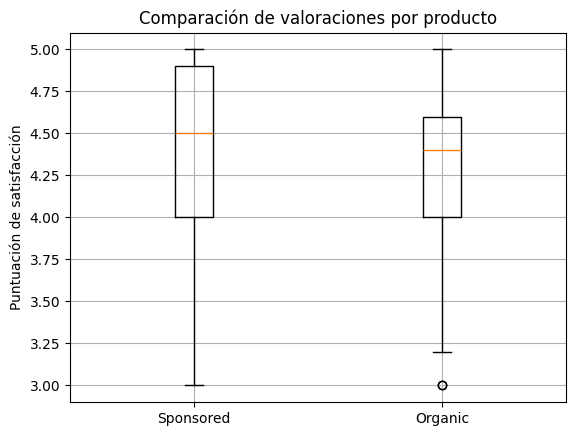

Estadístico U: 1063236.00
Valor p: 0.0000
Hay una diferencia significativa en la valoración de los productos.


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
# Gráfico de cajas
plt.boxplot([grupo1, grupo2], labels=["Sponsored", "Organic"])
plt.title("Comparación de valoraciones por producto")
plt.ylabel("Puntuación de satisfacción")
plt.grid(True)
plt.show()

# Prueba de Mann-Whitney U
stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p:.4f}")

if p < 0.05:
    print("Hay una diferencia significativa en la valoración de los productos.")
else:
    print("No se detecta una diferencia significativa.")

## 3.2 ¿ Existe una diferencia significativa entre las ventas de los productos patrocinados y los que no ?

In [39]:
peripherals[peripherals.is_sponsored == 'Sponsored'].purchased_last_month.mean(), peripherals[peripherals.is_sponsored == 'Organic'].purchased_last_month.mean()

(5359.210526315789, 352.5328330206379)

## NORMALIDAD DE PURCHASED_LAST_MONTH

100%|██████████| 10000/10000 [00:01<00:00, 8999.33it/s]


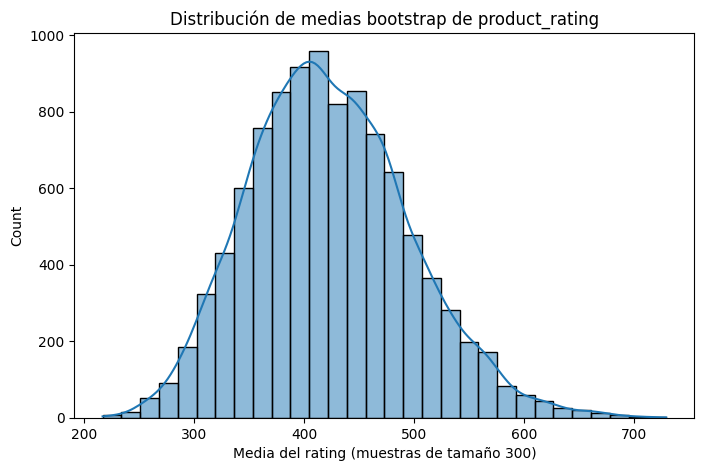

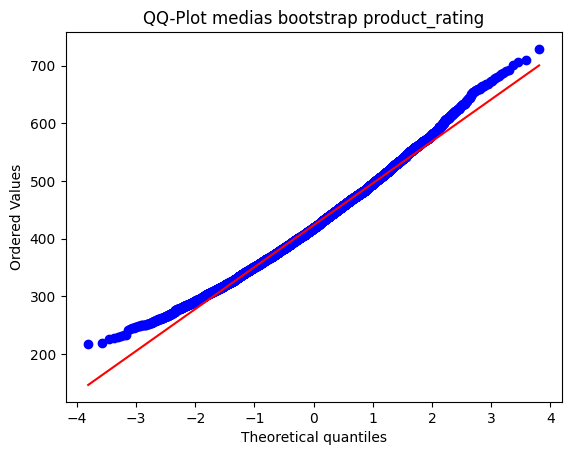

In [40]:
data = peripherals['purchased_last_month'].dropna()

df_boot = boot(data)

paint(df_boot["medias"])

In [41]:
test_normalidad(stats.shapiro,df_boot["medias"])

Estadístico: 0.9922988438723641
p-valor: 8.17779744577587e-23
Los datos NO siguen una distribución normal.


c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [42]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 210.56348342659686
p-valor: 1.8911262752707486e-46
Los datos NO siguen una distribución normal.


## VARIANZAS

In [44]:
peripherals[peripherals.is_sponsored == 'Sponsored'].purchased_last_month.dropna().std(), peripherals[peripherals.is_sponsored == 'Organic'].purchased_last_month.dropna().std()

(4868.429116520945, 968.6829320728057)

In [45]:
import numpy as np
from scipy import stats

# Creamos dos grupos con varianzas distintas

grupo1 = peripherals[peripherals.is_sponsored == 'Sponsored'].purchased_last_month.dropna()
grupo2 = peripherals[peripherals.is_sponsored == 'Organic'].purchased_last_month.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.4f}. Estadístico: {stat:.4f}")

Prueba de Levene (varianza): p-value = 0.0000. Estadístico: 659.6798


### Lo que nos dice la prueba de Levene es que las varianzas NO son iguales

- Por lo tanto aplicaré el test de Welch, usado como la prueba t de Student para variables de varianza desigual, asume normalidad

In [46]:
import numpy as np
from scipy import stats

# Aplicamos la prueba de Welch (t-test con varianzas desiguales)
t_stat, p_value = stats.ttest_ind(grupo1, grupo2, equal_var=False)

print(f"\nPrueba de Welch:")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación del resultado
alpha = 0.05
if p_value < alpha:
    print("Las medias son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para afirmar que las medias son diferentes.")


Prueba de Welch:
Estadístico t: 6.3377
Valor p: 0.0000
Las medias son significativamente diferentes.


-BRUNNER-MUNZEL: NO NORMALIDAD CON VARIANZAS DISTINTAS

In [47]:
# Aplicar el test de Brunner-Munzel
stat, p_value = stats.brunnermunzel(grupo1, grupo2)

print(f"Estadístico W: {stat}")
print(f"P-valor: {p_value}")

if p_value < 0.05:
    print("Rechazamos H0: Existe una diferencia significativa entre las ventas.")
    # Para saber cuál es mejor, mira las medianas o medias
    if np.mean(grupo1) > np.mean(grupo2):
        print("Los productos Patrocinados tienden a tener mmás ventas")
    else:
        print("Los productos Orgánicos tienden a tener más ventas")
else:
    print("No podemos rechazar H0: No hay evidencia suficiente de diferencia.")

Estadístico W: -3.377448760153495
P-valor: 0.001731759140136599
Rechazamos H0: Existe una diferencia significativa entre las ventas.
Los productos Patrocinados tienden a tener mmás ventas


## 3.3 ¿Existe alguna relación entre el patrocinio (o no) y la etiqueta de best_seller?

- ### Dividiré entre aquellos que tienen etiqueta de best seller y los que no

In [48]:
len(peripherals[peripherals.is_best_seller != 'No Badge'])

87

In [49]:
peripherals[['is_best_seller', 'is_sponsored']]

,is_best_seller,is_sponsored
9,Best Seller,Organic
30,No Badge,Sponsored
55,No Badge,Organic
61,No Badge,Organic
73,No Badge,Sponsored
...,...,...
42598,No Badge,Organic
42602,No Badge,Sponsored
42604,No Badge,Organic
42628,No Badge,Organic


In [50]:
tabla_observada = pd.crosstab(peripherals["is_best_seller"], peripherals["is_sponsored"])
n = tabla_observada.sum().sum()
print("Total Elementos", n)
tabla_observada

Total Elementos 3517


is_sponsored,Organic,Sponsored
is_best_seller,,
Amazon's,31,12
Best Seller,21,14
Limited time deal,1,0
No Badge,2888,542
Save 9%,0,8


In [51]:
print(peripherals["is_best_seller"].unique())
peripherals["is_best_seller"].value_counts(normalize=True)

['Best Seller' 'No Badge' "Amazon's" 'Limited time deal' 'Save 9%']


is_best_seller
No Badge             0.975263
Amazon's             0.012226
Best Seller          0.009952
Save 9%              0.002275
Limited time deal    0.000284
Name: proportion, dtype: float64

In [52]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Ver la tabla de frecuencias observada
tabla_observada = pd.crosstab(peripherals["is_best_seller"], peripherals["is_sponsored"])
print("Tabla de Frecuencias Observada:\n", tabla_observada)

# Calcular el test de Chi-cuadrado
chi2, p, dof, tabla_esperada = chi2_contingency(tabla_observada)

# Mostrar resultados
print(f"Valor p: {p}")

# Interpretación del resultado
alpha = 0.05
if p < alpha:
    print("\nRechazamos la hipótesis nula: Existe una asociación significativa entre la etiqueta de best_seller y el patrocinio")
else:
    print("\nNo se puede rechazar la hipótesis nula: No se encontró asociación significativa entre la etiqueta de best_seller y el patrocinio")


Tabla de Frecuencias Observada:
 is_sponsored       Organic  Sponsored
is_best_seller                       
Amazon's                31         12
Best Seller             21         14
Limited time deal        1          0
No Badge              2888        542
Save 9%                  0          8
Valor p: 2.49928026274342e-12

Rechazamos la hipótesis nula: Existe una asociación significativa entre la etiqueta de best_seller y el patrocinio


# 4. CORRELACIONES

### Estudiando los outliers también grafiqué ciertas relaciones entre pares de variables

In [57]:
import plotly.express as px
fig = px.scatter(peripherals, y='product_rating', x='original_price', title="Scatter Plot con Plotly",  trendline="ols",)
fig.show()
df = peripherals.groupby('product_rating')['original_price'].mean()
fig = px.scatter(df, y=df.index, x=df.values, title="Scatter Plot con Plotly", trendline="ols",)
fig.show()

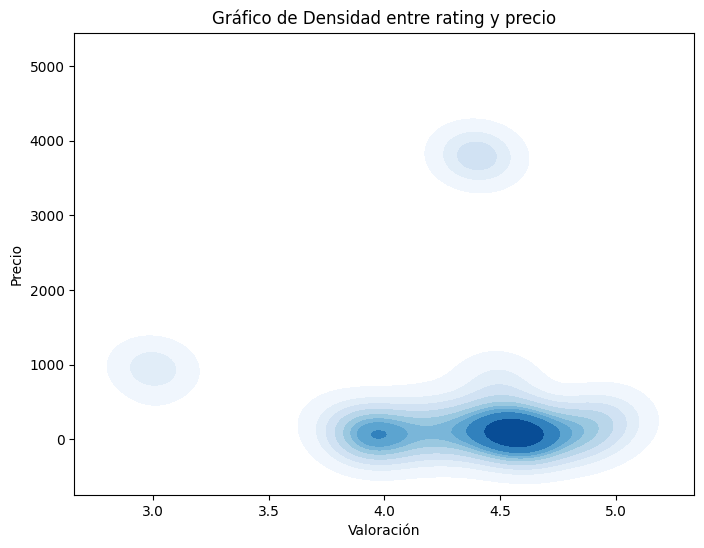

In [59]:
import seaborn as sns

# Gráfico de densidad para ver la relación entre BBVA y Santander
plt.figure(figsize=(8, 6))
sns.kdeplot(x='product_rating', y='original_price', data=peripherals, fill=True, cmap="Blues")
plt.title('Gráfico de Densidad entre rating y precio')
plt.xlabel('Valoración')
plt.ylabel('Precio')
plt.show()

In [60]:
v = peripherals.groupby(['is_sponsored', 'is_best_seller'])['purchased_last_month'].sum().reset_index()
v.pivot(index='is_best_seller', columns='is_sponsored', values='purchased_last_month')

is_sponsored,Organic,Sponsored
is_best_seller,,
Amazon's,11150.0,60100.0
Best Seller,84600.0,138000.0
Limited time deal,3000.0,NaN
No Badge,840750.0,5550.0
Save 9%,NaN,0.0


- ### Ventas en el último mes dependiendo de su etiqueta de best_seller y sponsored

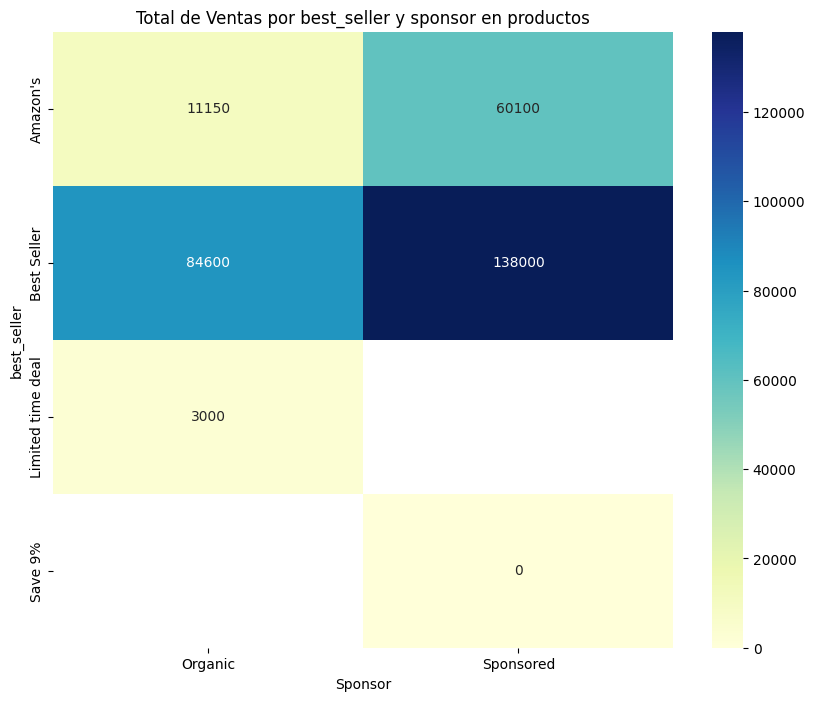

In [61]:
ventas_por_sponsored = peripherals_sin_NoBadge.groupby(['is_sponsored', 'is_best_seller'])['purchased_last_month'].sum().reset_index()
# ventas_por_sponsored = ventas_por_sponsored.sort_values('N.Mes')

# Formato ancho
ventas_pivot = ventas_por_sponsored.pivot(index='is_best_seller', columns='is_sponsored', values='purchased_last_month')
# ventas_pivot.columns = ventas_por_sponsored.drop_duplicates(subset=['N.Mes'])['MES']

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(ventas_pivot, annot=True, fmt=".0f", cmap="YlGnBu")

# Añadir título y etiquetas
plt.title('Total de Ventas por best_seller y sponsor en productos')
plt.xlabel('Sponsor')
plt.ylabel('best_seller')
plt.show()

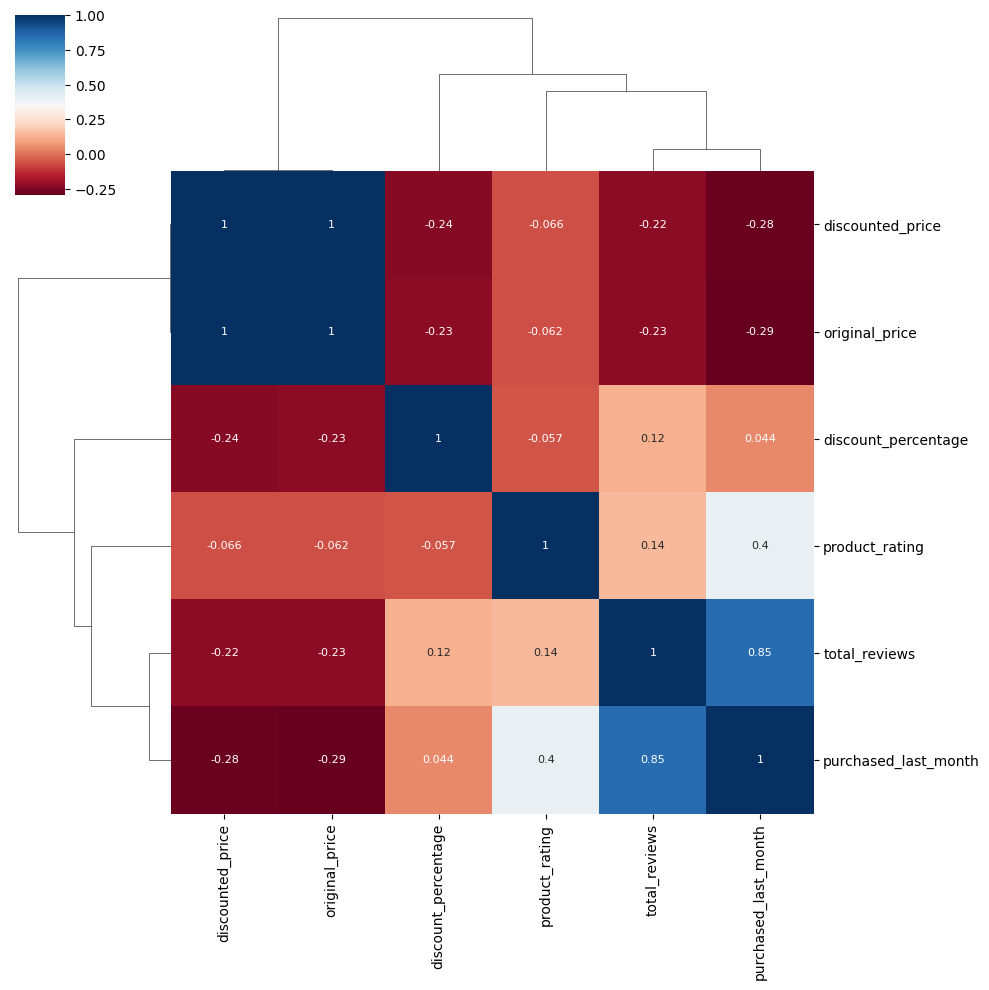

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(peripherals_sin_NoBadge[['product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']].corr(),
                   method = 'complete',
                   cmap   = 'RdBu',
                   annot  = True,
                   annot_kws = {'size': 8})

### POSITIVAS DE MAYOR A MENOR

- total_reviews vs purchased_last_month = 0.85 (Muy alta positiva): Los productos que históricamente tienen muchas reseñas son los que más se han vendido el último mes.

- Product_rating y Purchased_last_month: cuanto más alta es la valoración, más se venden. 0.4


- Product_rating y total_reviews: leve, pero a más reviews más alta es la valoración 0.14

- Porcentaje de descuento y total de reviews: parece que a más alto es el descuento más numero de reviews hay, no creo que sea relevante 0.12

- Discount_percentage y purchased last month: leve, pero a mayor porcentaje más se vende, resulta obvio 0.044

### NEGATIVAS DE MAYOR A MENOR

- Precio y ventas: a mayor precio, menos ventas. 0.29 y 0.28

- Precio y total de reviews: a mayor precio, menos reviews, menos ventas... 0.23 y 0.22

- Precios y porcentajes de descuento: a más altos menor es el descuento 0.23 y 0.24

- Precios y descuento con rating: A precios más altos menor es el rating